# Question 2: Image Denoising using Denoising Autoencoder

we implement a Convolutional Denoising Autoencoder (DAE) to reconstruct clean images from noisy inputs using the CIFAR-10 dataset.

## Tasks Overview:
1. Dataset Preparation
2. Noise Injection (Gaussian & Salt-and-Pepper)
3. Denoising Autoencoder Model Design
4. Model Training
5. Evaluation and Visualization
6. Experimental Study

## 1. Setup and Import Libraries

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Dataset Preparation - Load CIFAR-10

We load the CIFAR-10 dataset and normalize the images to [0, 1] range. The dataset contains 60,000 32x32 color images in 10 classes.

In [2]:
# Define transformation: Convert to tensor and normalize to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, 
                                            download=True, transform=transform)

# Extract images and labels
train_images = train_dataset.data / 255.0  # Normalize to [0, 1]
test_images = test_dataset.data / 255.0

# Convert to PyTorch tensors and permute dimensions to (N, C, H, W)
train_images = torch.FloatTensor(train_images).permute(0, 3, 1, 2)
test_images = torch.FloatTensor(test_images).permute(0, 3, 1, 2)

# Split training data into train and validation sets (90-10 split)
train_images, val_images = train_test_split(train_images, test_size=0.1, random_state=42)

print(f"Training set size: {train_images.shape}")
print(f"Validation set size: {val_images.shape}")
print(f"Test set size: {test_images.shape}")
print(f"Image shape: {train_images[0].shape} (C x H x W)")

Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [00:02<00:00, 80.0MB/s] 


Training set size: torch.Size([45000, 3, 32, 32])
Validation set size: torch.Size([5000, 3, 32, 32])
Test set size: torch.Size([10000, 3, 32, 32])
Image shape: torch.Size([3, 32, 32]) (C x H x W)


## 3. Noise Injection Functions

We implement two types of noise:
1. **Gaussian Noise**: Adds random noise from a Gaussian distribution
2. **Salt-and-Pepper Noise**: Randomly sets pixels to 0 (pepper) or 1 (salt)

Visualizing different noise types on sample images:


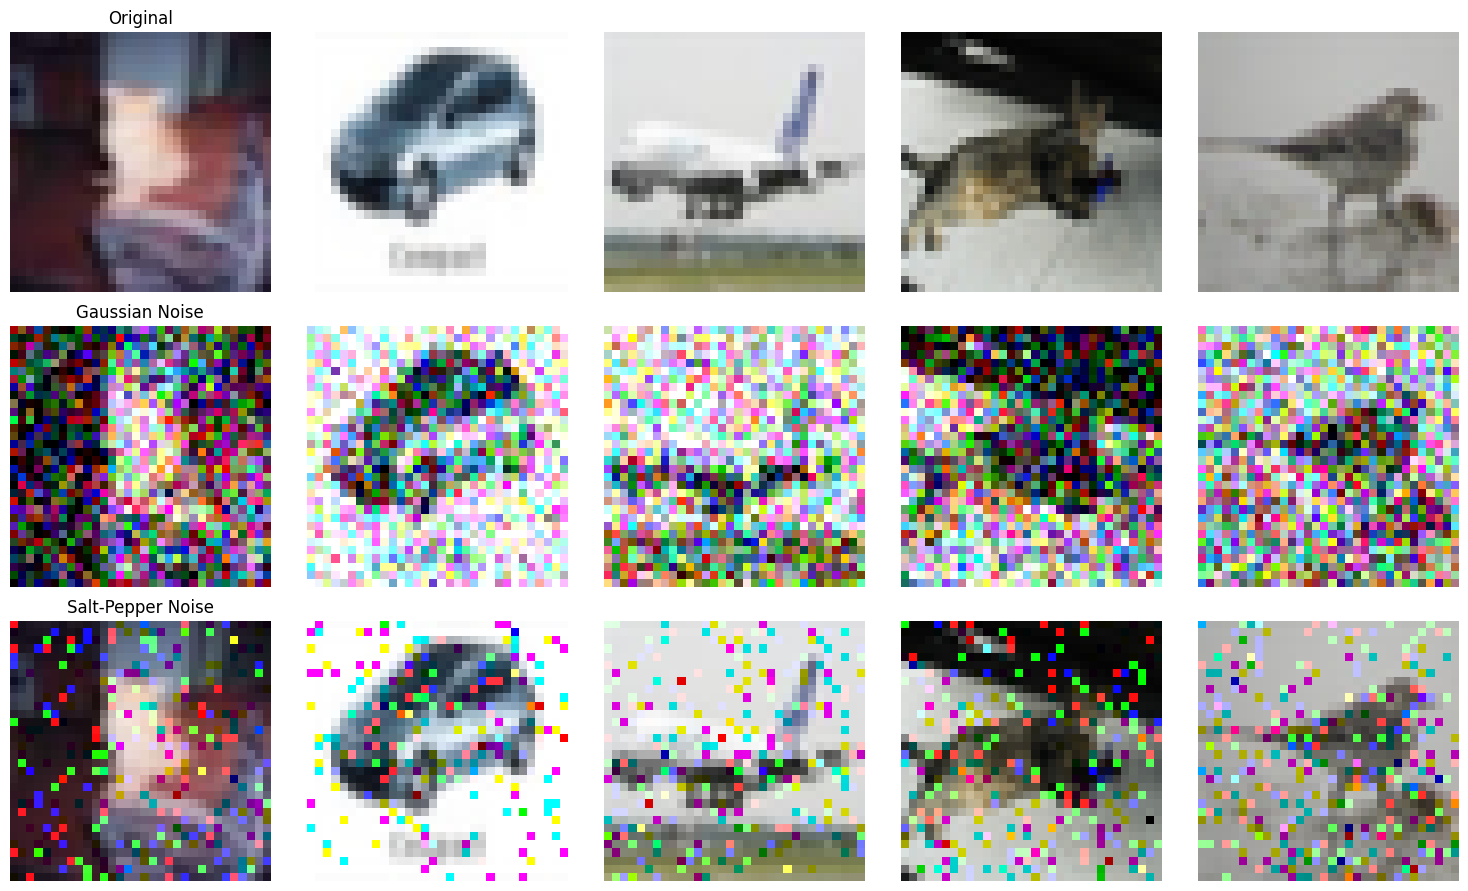

In [3]:
def add_gaussian_noise(images, noise_factor=0.3):
    """
    Add Gaussian noise to images.
    
    Args:
        images: Tensor of shape (N, C, H, W)
        noise_factor: Standard deviation of the Gaussian noise
    
    Returns:
        Noisy images clipped to [0, 1]
    """
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

def add_salt_pepper_noise(images, salt_prob=0.05, pepper_prob=0.05):
    """
    Add salt-and-pepper noise to images.
    
    Args:
        images: Tensor of shape (N, C, H, W)
        salt_prob: Probability of a pixel being set to 1 (salt)
        pepper_prob: Probability of a pixel being set to 0 (pepper)
    
    Returns:
        Noisy images with salt-and-pepper noise
    """
    noisy_images = images.clone()
    
    # Add salt (white pixels)
    salt_mask = torch.rand_like(images) < salt_prob
    noisy_images[salt_mask] = 1.0
    
    # Add pepper (black pixels)
    pepper_mask = torch.rand_like(images) < pepper_prob
    noisy_images[pepper_mask] = 0.0
    
    return noisy_images

# Visualize original vs noisy images
def visualize_noise(images, num_samples=5):
    """Visualize original, Gaussian noisy, and salt-pepper noisy images."""
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 9))
    
    sample_images = images[:num_samples]
    gaussian_noisy = add_gaussian_noise(sample_images, noise_factor=0.3)
    sp_noisy = add_salt_pepper_noise(sample_images, salt_prob=0.05, pepper_prob=0.05)
    
    for i in range(num_samples):
        # Original
        axes[0, i].imshow(sample_images[i].permute(1, 2, 0).cpu().numpy())
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=12)
        
        # Gaussian noise
        axes[1, i].imshow(gaussian_noisy[i].permute(1, 2, 0).cpu().numpy())
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Gaussian Noise', fontsize=12)
        
        # Salt-and-pepper noise
        axes[2, i].imshow(sp_noisy[i].permute(1, 2, 0).cpu().numpy())
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_title('Salt-Pepper Noise', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Visualize noise examples
print("Visualizing different noise types on sample images:")
visualize_noise(train_images)

## 4. Denoising Autoencoder Architecture

We design a Convolutional Denoising Autoencoder with:
- **Encoder**: Progressively reduces spatial dimensions while increasing feature channels
- **Bottleneck**: Compressed latent representation
- **Decoder**: Reconstructs the image using transposed convolutions

**Architecture Details:**
- Input: 3 x 32 x 32 (RGB image)
- Encoder: Conv layers with ReLU activation and MaxPooling
- Bottleneck: Configurable size (default: 128 dimensions)
- Decoder: TransposeConv layers for upsampling
- Output: 3 x 32 x 32 (Reconstructed image) with Sigmoid activation

In [4]:
class DenoisingAutoencoder(nn.Module):
    """
    Convolutional Denoising Autoencoder for image reconstruction.
    
    Architecture:
    - Encoder: 3 convolutional layers with ReLU and MaxPooling
    - Bottleneck: Fully connected layer
    - Decoder: 3 transposed convolutional layers for upsampling
    """
    
    def __init__(self, bottleneck_size=128):
        super(DenoisingAutoencoder, self).__init__()
        
        # Encoder network
        # Input: 3 x 32 x 32
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32 x 16 x 16
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 64 x 16 x 16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64 x 8 x 8
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 128 x 8 x 8
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 128 x 4 x 4
        )
        
        # Bottleneck (compressed representation)
        self.bottleneck_encoder = nn.Linear(128 * 4 * 4, bottleneck_size)
        self.bottleneck_decoder = nn.Linear(bottleneck_size, 128 * 4 * 4)
        
        # Decoder network
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 64 x 8 x 8
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32 x 16 x 16
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 3 x 32 x 32
            nn.Sigmoid()  # Output in range [0, 1]
        )
        
        self.bottleneck_size = bottleneck_size
    
    def forward(self, x):
        # Encode
        x = self.encoder(x)
        
        # Flatten and pass through bottleneck
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        x = self.bottleneck_encoder(x)
        x = self.bottleneck_decoder(x)
        x = x.view(batch_size, 128, 4, 4)
        
        # Decode
        x = self.decoder(x)
        
        return x

# Create model instance
model = DenoisingAutoencoder(bottleneck_size=128).to(device)

# Print model architecture
print("=" * 70)
print("Denoising Autoencoder Architecture")
print("=" * 70)
print(model)
print("=" * 70)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Denoising Autoencoder Architecture
DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck_encoder): Linear(in_features=2048, out_features=128, bias=True)
  (bottleneck_decoder): Linear(in_features=128, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), 

## 5. Training Setup

We use:
- **Loss Function**: Mean Squared Error (MSE) for reconstruction loss
- **Optimizer**: Adam optimizer with learning rate 0.001
- **Batch Size**: 128
- **Epochs**: 20

In [7]:
def train_model(model, train_images, val_images, noise_type='gaussian', 
                noise_factor=0.3, epochs=20, batch_size=128, lr=0.001):
    """
    Train the denoising autoencoder.
    
    Args:
        model: The autoencoder model
        train_images: Training images
        val_images: Validation images
        noise_type: 'gaussian' or 'salt_pepper'
        noise_factor: Noise intensity (std for Gaussian, prob for S&P)
        epochs: Number of training epochs
        batch_size: Batch size for training
        lr: Learning rate
    
    Returns:
        train_losses: List of training losses
        val_losses: List of validation losses
    """
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Create data loaders
    train_dataset = TensorDataset(train_images)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    train_losses = []
    val_losses = []
    
    print(f"\nTraining with {noise_type} noise (factor={noise_factor})...")
    print("=" * 70)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_idx, (clean_images,) in enumerate(train_loader):
            clean_images = clean_images.to(device)
            
            # Add noise to images
            if noise_type == 'gaussian':
                noisy_images = add_gaussian_noise(clean_images, noise_factor)
            else:  # salt_pepper
                noisy_images = add_salt_pepper_noise(clean_images, noise_factor, noise_factor)
            
            # Forward pass
            outputs = model(noisy_images)
            loss = criterion(outputs, clean_images)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Calculate average training loss
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            val_clean = val_images.to(device)
            
            # Add noise to validation images
            if noise_type == 'gaussian':
                val_noisy = add_gaussian_noise(val_clean, noise_factor)
            else:
                val_noisy = add_salt_pepper_noise(val_clean, noise_factor, noise_factor)
            
            # Forward pass (in batches to avoid memory issues)
            val_outputs = []
            for i in range(0, len(val_clean), batch_size):
                batch = val_noisy[i:i+batch_size]
                outputs = model(batch)
                val_outputs.append(outputs)
            
            val_outputs = torch.cat(val_outputs, dim=0)
            val_loss = criterion(val_outputs, val_clean).item()
        
        val_losses.append(val_loss)
        
        # Print progress
        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Loss: {avg_train_loss:.6f} - "
              f"Val Loss: {val_loss:.6f}")
    
    print("=" * 70)
    print("Training completed!")
    
    return train_losses, val_losses

# Training hyperparameters
EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 0.001

### 5.1 Train with Gaussian Noise


Training with gaussian noise (factor=0.3)...
Epoch [1/20] - Train Loss: 0.025196 - Val Loss: 0.016371
Epoch [2/20] - Train Loss: 0.014602 - Val Loss: 0.013382
Epoch [3/20] - Train Loss: 0.012654 - Val Loss: 0.012069
Epoch [4/20] - Train Loss: 0.011468 - Val Loss: 0.011592
Epoch [5/20] - Train Loss: 0.010728 - Val Loss: 0.010413
Epoch [6/20] - Train Loss: 0.010213 - Val Loss: 0.010075
Epoch [7/20] - Train Loss: 0.009844 - Val Loss: 0.009769
Epoch [8/20] - Train Loss: 0.009538 - Val Loss: 0.009442
Epoch [9/20] - Train Loss: 0.009297 - Val Loss: 0.009363
Epoch [10/20] - Train Loss: 0.009092 - Val Loss: 0.009055
Epoch [11/20] - Train Loss: 0.008907 - Val Loss: 0.008921
Epoch [12/20] - Train Loss: 0.008766 - Val Loss: 0.008806
Epoch [13/20] - Train Loss: 0.008639 - Val Loss: 0.008736
Epoch [14/20] - Train Loss: 0.008502 - Val Loss: 0.008498
Epoch [15/20] - Train Loss: 0.008419 - Val Loss: 0.008447
Epoch [16/20] - Train Loss: 0.008316 - Val Loss: 0.008465
Epoch [17/20] - Train Loss: 0.00822

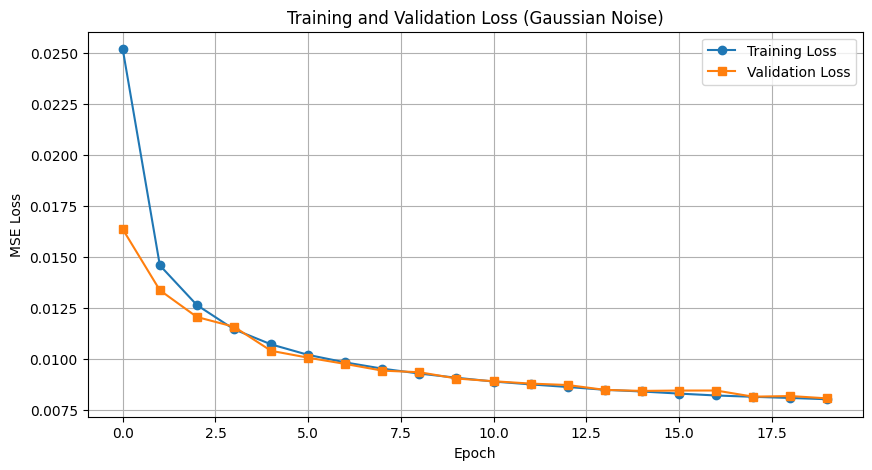

In [8]:
# Train the model with Gaussian noise
train_losses, val_losses = train_model(
    model, 
    train_images, 
    val_images, 
    noise_type='gaussian',
    noise_factor=0.3,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE
)

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss (Gaussian Noise)')
plt.legend()
plt.grid(True)
plt.show()

### 5.2 Train a Separate Model with Salt-and-Pepper Noise

Since salt-and-pepper noise has different characteristics than Gaussian noise, we train a separate model specifically for this noise type.

Training model for Salt-and-Pepper noise...

Training with salt_pepper noise (factor=0.05)...
Epoch [1/20] - Train Loss: 0.026658 - Val Loss: 0.015779
Epoch [2/20] - Train Loss: 0.013725 - Val Loss: 0.012248
Epoch [3/20] - Train Loss: 0.011391 - Val Loss: 0.011226
Epoch [4/20] - Train Loss: 0.010057 - Val Loss: 0.009542
Epoch [5/20] - Train Loss: 0.009224 - Val Loss: 0.009160
Epoch [6/20] - Train Loss: 0.008694 - Val Loss: 0.008450
Epoch [7/20] - Train Loss: 0.008196 - Val Loss: 0.008162
Epoch [8/20] - Train Loss: 0.007826 - Val Loss: 0.007718
Epoch [9/20] - Train Loss: 0.007530 - Val Loss: 0.007439
Epoch [10/20] - Train Loss: 0.007279 - Val Loss: 0.007752
Epoch [11/20] - Train Loss: 0.007052 - Val Loss: 0.007030
Epoch [12/20] - Train Loss: 0.006860 - Val Loss: 0.006989
Epoch [13/20] - Train Loss: 0.006688 - Val Loss: 0.006652
Epoch [14/20] - Train Loss: 0.006539 - Val Loss: 0.006508
Epoch [15/20] - Train Loss: 0.006402 - Val Loss: 0.006648
Epoch [16/20] - Train Loss: 0.006271 - Val Lo

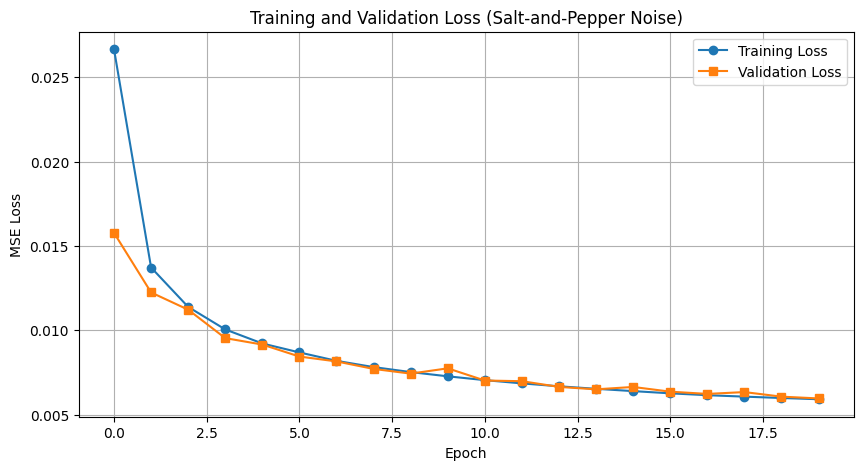

In [9]:
# Create a new model for salt-and-pepper noise
model_sp = DenoisingAutoencoder(bottleneck_size=128).to(device)
print("Training model for Salt-and-Pepper noise...")

# Train the model with salt-and-pepper noise
train_losses_sp, val_losses_sp = train_model(
    model_sp, 
    train_images, 
    val_images, 
    noise_type='salt_pepper',
    noise_factor=0.05,  # 5% probability for both salt and pepper
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE
)

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses_sp, label='Training Loss', marker='o')
plt.plot(val_losses_sp, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss (Salt-and-Pepper Noise)')
plt.legend()
plt.grid(True)
plt.show()

### 5.3 Evaluate Salt-and-Pepper Noise Model

Evaluating Salt-and-Pepper noise model on test set...

Evaluation Results (Salt-and-Pepper Noise):
MSE:  0.006120
PSNR: 22.70 dB
SSIM: 0.7391

Visualizing Salt-and-Pepper reconstruction results:


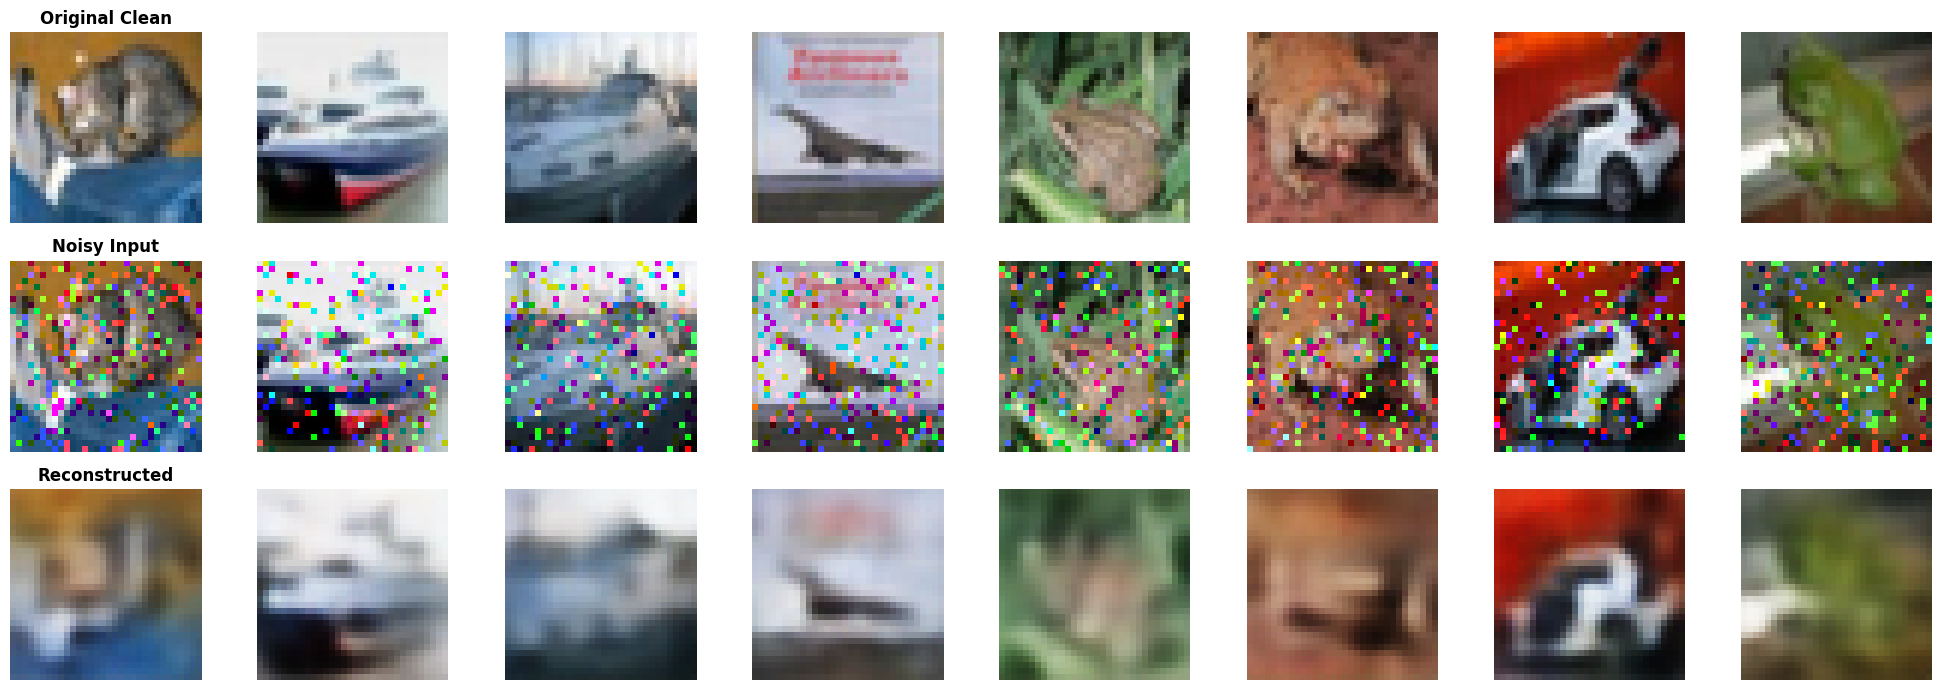

In [14]:
# Evaluate the salt-and-pepper model
print("Evaluating Salt-and-Pepper noise model on test set...")
results_sp, (clean_imgs_sp, noisy_imgs_sp, recon_imgs_sp) = evaluate_model(
    model_sp, test_images, noise_type='salt_pepper', noise_factor=0.05, num_samples=100
)

print("\nEvaluation Results (Salt-and-Pepper Noise):")
print("=" * 50)
print(f"MSE:  {results_sp['MSE']:.6f}")
print(f"PSNR: {results_sp['PSNR']:.2f} dB")
print(f"SSIM: {results_sp['SSIM']:.4f}")
print("=" * 50)

# Visualize salt-and-pepper results
print("\nVisualizing Salt-and-Pepper reconstruction results:")
visualize_results(clean_imgs_sp, noisy_imgs_sp, recon_imgs_sp, num_samples=8)

## 6. Evaluation Metrics

We evaluate reconstruction quality using three metrics:
1. **MSE (Mean Squared Error)**: Average squared difference between pixels
2. **PSNR (Peak Signal-to-Noise Ratio)**: Measures reconstruction quality in dB (higher is better)
3. **SSIM (Structural Similarity Index)**: Perceptual similarity metric (range 0-1, higher is better)

In [11]:
def evaluate_model(model, images, noise_type='gaussian', noise_factor=0.3, num_samples=100):
    """
    Evaluate the model using MSE, PSNR, and SSIM metrics.
    
    Args:
        model: The trained autoencoder model
        images: Clean images to evaluate
        noise_type: 'gaussian' or 'salt_pepper'
        noise_factor: Noise intensity
        num_samples: Number of samples to evaluate
    
    Returns:
        Dictionary with average metrics
    """
    model.eval()
    
    # Select subset of images
    images = images[:num_samples].to(device)
    
    # Add noise
    if noise_type == 'gaussian':
        noisy_images = add_gaussian_noise(images, noise_factor)
    else:
        noisy_images = add_salt_pepper_noise(images, noise_factor, noise_factor)
    
    # Get reconstructions
    with torch.no_grad():
        reconstructed = model(noisy_images)
    
    # Move to CPU and convert to numpy for metric calculation
    clean_np = images.cpu().numpy()
    noisy_np = noisy_images.cpu().numpy()
    recon_np = reconstructed.cpu().numpy()
    
    # Calculate metrics for each image
    mse_scores = []
    psnr_scores = []
    ssim_scores = []
    
    for i in range(num_samples):
        clean_img = clean_np[i].transpose(1, 2, 0)  # CHW -> HWC
        noisy_img = noisy_np[i].transpose(1, 2, 0)
        recon_img = recon_np[i].transpose(1, 2, 0)
        
        # MSE
        mse = np.mean((clean_img - recon_img) ** 2)
        mse_scores.append(mse)
        
        # PSNR
        psnr_val = psnr(clean_img, recon_img, data_range=1.0)
        psnr_scores.append(psnr_val)
        
        # SSIM
        ssim_val = ssim(clean_img, recon_img, data_range=1.0, channel_axis=2)
        ssim_scores.append(ssim_val)
    
    results = {
        'MSE': np.mean(mse_scores),
        'PSNR': np.mean(psnr_scores),
        'SSIM': np.mean(ssim_scores)
    }
    
    return results, (clean_np, noisy_np, recon_np)

# Evaluate on test set
print("Evaluating model on test set...")
results, (clean_imgs, noisy_imgs, recon_imgs) = evaluate_model(
    model, test_images, noise_type='gaussian', noise_factor=0.3, num_samples=100
)

print("\nEvaluation Results:")
print("=" * 50)
print(f"MSE:  {results['MSE']:.6f}")
print(f"PSNR: {results['PSNR']:.2f} dB")
print(f"SSIM: {results['SSIM']:.4f}")
print("=" * 50)

Evaluating model on test set...

Evaluation Results:
MSE:  0.008191
PSNR: 21.27 dB
SSIM: 0.6608


## 7. Visualization of Results

Visualize original clean images, noisy images, and reconstructed (denoised) images side by side.

Visualizing reconstruction results:


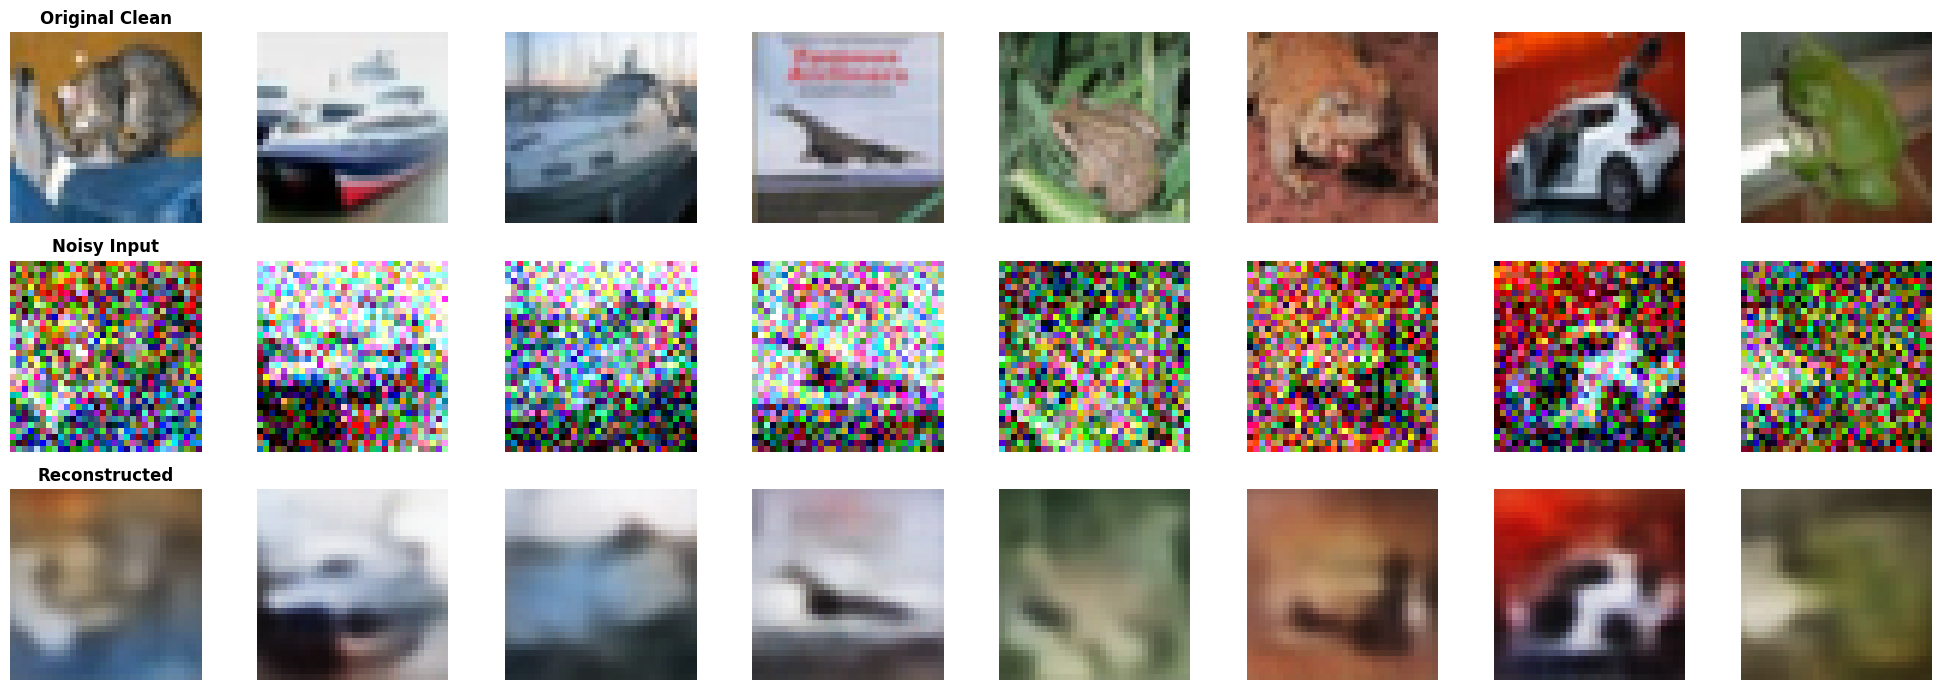

In [13]:
def visualize_results(clean_imgs, noisy_imgs, recon_imgs, num_samples=8):
    """
    Visualize original, noisy, and reconstructed images.
    
    Args:
        clean_imgs: Original clean images (numpy array)
        noisy_imgs: Noisy images (numpy array)
        recon_imgs: Reconstructed images (numpy array)
        num_samples: Number of samples to display
    """
    fig, axes = plt.subplots(3, num_samples, figsize=(20, 7))
    
    for i in range(num_samples):
        # Original clean image
        axes[0, i].imshow(clean_imgs[i].transpose(1, 2, 0))
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original Clean', fontsize=12, fontweight='bold')
        
        # Noisy image
        axes[1, i].imshow(noisy_imgs[i].transpose(1, 2, 0))
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Noisy Input', fontsize=12, fontweight='bold')
        
        # Reconstructed image
        axes[2, i].imshow(recon_imgs[i].transpose(1, 2, 0))
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_title('Reconstructed', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Visualize results
print("Visualizing reconstruction results:")
visualize_results(clean_imgs, noisy_imgs, recon_imgs, num_samples=8)

## 8. Experimental Study

In this section, we conduct comprehensive experiments to analyze:
1. **Effect of Different Noise Levels**: How does performance change with varying noise intensities?
2. **Effect of Different Bottleneck Sizes**: How does the compression level affect reconstruction quality?

These experiments will help us understand the model's robustness and capacity requirements.

### 8.1 Experiment 1: Effect of Different Noise Levels

We train models with varying noise intensities and compare their reconstruction performance.

In [15]:
# Experiment with different Gaussian noise levels
gaussian_noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]
gaussian_results = {'noise_level': [], 'MSE': [], 'PSNR': [], 'SSIM': []}

print("Experimenting with different Gaussian noise levels...")
print("=" * 70)

for noise_level in gaussian_noise_levels:
    print(f"\nTraining with Gaussian noise level: {noise_level}")
    
    # Create and train model
    temp_model = DenoisingAutoencoder(bottleneck_size=128).to(device)
    train_model(temp_model, train_images[:10000], val_images[:1000], 
                noise_type='gaussian', noise_factor=noise_level, 
                epochs=10, batch_size=BATCH_SIZE, lr=LEARNING_RATE)
    
    # Evaluate
    results, _ = evaluate_model(temp_model, test_images[:500], 
                                noise_type='gaussian', noise_factor=noise_level, 
                                num_samples=100)
    
    gaussian_results['noise_level'].append(noise_level)
    gaussian_results['MSE'].append(results['MSE'])
    gaussian_results['PSNR'].append(results['PSNR'])
    gaussian_results['SSIM'].append(results['SSIM'])
    
    print(f"Results - MSE: {results['MSE']:.6f}, PSNR: {results['PSNR']:.2f} dB, SSIM: {results['SSIM']:.4f}")

print("\n" + "=" * 70)

Experimenting with different Gaussian noise levels...

Training with Gaussian noise level: 0.1

Training with gaussian noise (factor=0.1)...
Epoch [1/10] - Train Loss: 0.040489 - Val Loss: 0.027622
Epoch [2/10] - Train Loss: 0.024630 - Val Loss: 0.022201
Epoch [3/10] - Train Loss: 0.020656 - Val Loss: 0.018262
Epoch [4/10] - Train Loss: 0.017008 - Val Loss: 0.016161
Epoch [5/10] - Train Loss: 0.015352 - Val Loss: 0.014739
Epoch [6/10] - Train Loss: 0.014189 - Val Loss: 0.013828
Epoch [7/10] - Train Loss: 0.013368 - Val Loss: 0.013245
Epoch [8/10] - Train Loss: 0.012726 - Val Loss: 0.012603
Epoch [9/10] - Train Loss: 0.012168 - Val Loss: 0.012155
Epoch [10/10] - Train Loss: 0.011682 - Val Loss: 0.011832
Training completed!
Results - MSE: 0.011879, PSNR: 19.72 dB, SSIM: 0.5470

Training with Gaussian noise level: 0.2

Training with gaussian noise (factor=0.2)...
Epoch [1/10] - Train Loss: 0.043693 - Val Loss: 0.029472
Epoch [2/10] - Train Loss: 0.025297 - Val Loss: 0.022527
Epoch [3/10] 

In [16]:
# Experiment with different Salt-and-Pepper noise levels
sp_noise_levels = [0.02, 0.05, 0.08, 0.10, 0.15]
sp_results = {'noise_level': [], 'MSE': [], 'PSNR': [], 'SSIM': []}

print("Experimenting with different Salt-and-Pepper noise levels...")
print("=" * 70)

for noise_level in sp_noise_levels:
    print(f"\nTraining with Salt-and-Pepper noise level: {noise_level}")
    
    # Create and train model
    temp_model = DenoisingAutoencoder(bottleneck_size=128).to(device)
    train_model(temp_model, train_images[:10000], val_images[:1000], 
                noise_type='salt_pepper', noise_factor=noise_level, 
                epochs=10, batch_size=BATCH_SIZE, lr=LEARNING_RATE)
    
    # Evaluate
    results, _ = evaluate_model(temp_model, test_images[:500], 
                                noise_type='salt_pepper', noise_factor=noise_level, 
                                num_samples=100)
    
    sp_results['noise_level'].append(noise_level)
    sp_results['MSE'].append(results['MSE'])
    sp_results['PSNR'].append(results['PSNR'])
    sp_results['SSIM'].append(results['SSIM'])
    
    print(f"Results - MSE: {results['MSE']:.6f}, PSNR: {results['PSNR']:.2f} dB, SSIM: {results['SSIM']:.4f}")

print("\n" + "=" * 70)

Experimenting with different Salt-and-Pepper noise levels...

Training with Salt-and-Pepper noise level: 0.02

Training with salt_pepper noise (factor=0.02)...
Epoch [1/10] - Train Loss: 0.049187 - Val Loss: 0.031216
Epoch [2/10] - Train Loss: 0.027179 - Val Loss: 0.024382
Epoch [3/10] - Train Loss: 0.021888 - Val Loss: 0.019739
Epoch [4/10] - Train Loss: 0.018460 - Val Loss: 0.017328
Epoch [5/10] - Train Loss: 0.016546 - Val Loss: 0.016022
Epoch [6/10] - Train Loss: 0.015115 - Val Loss: 0.014690
Epoch [7/10] - Train Loss: 0.014144 - Val Loss: 0.014073
Epoch [8/10] - Train Loss: 0.013533 - Val Loss: 0.014364
Epoch [9/10] - Train Loss: 0.012872 - Val Loss: 0.012908
Epoch [10/10] - Train Loss: 0.012288 - Val Loss: 0.012479
Training completed!
Results - MSE: 0.012403, PSNR: 19.53 dB, SSIM: 0.5342

Training with Salt-and-Pepper noise level: 0.05

Training with salt_pepper noise (factor=0.05)...
Epoch [1/10] - Train Loss: 0.043931 - Val Loss: 0.028963
Epoch [2/10] - Train Loss: 0.025922 - V

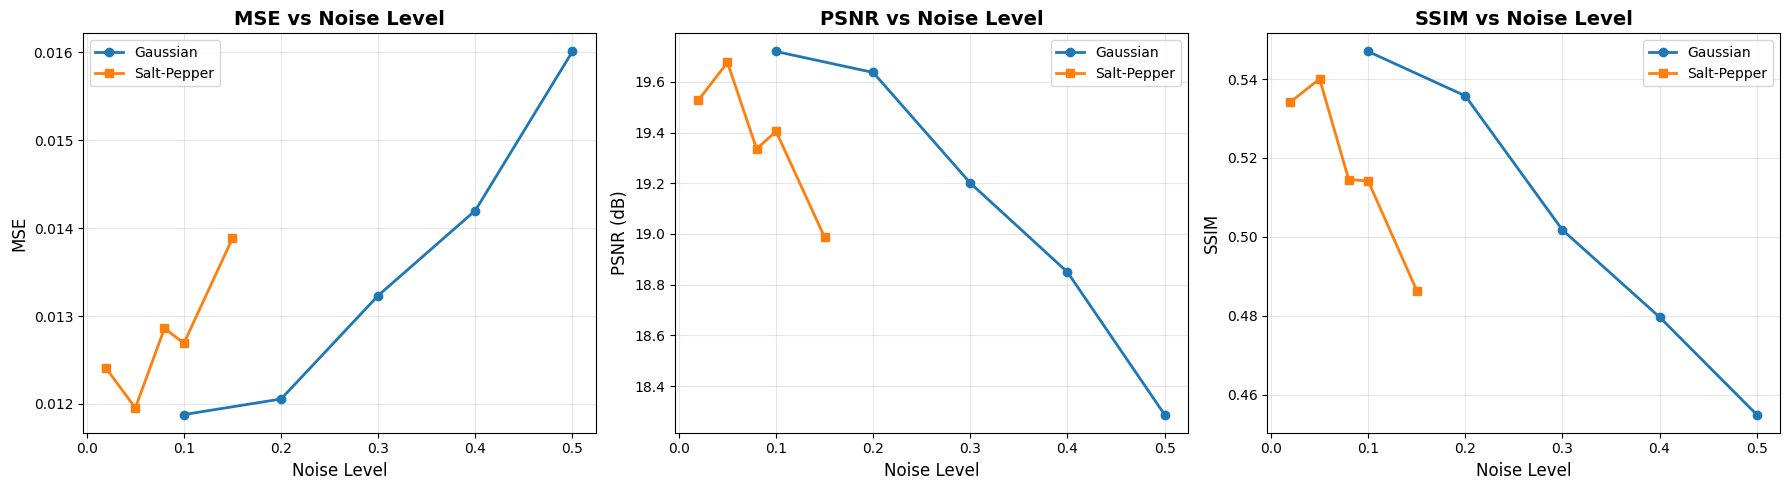


Observations:
- As noise level increases, reconstruction quality (PSNR, SSIM) decreases
- MSE increases with higher noise levels
- The model shows robustness to moderate noise levels


In [17]:
# Visualize the effect of noise levels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MSE vs Noise Level
axes[0].plot(gaussian_results['noise_level'], gaussian_results['MSE'], 
             marker='o', label='Gaussian', linewidth=2)
axes[0].plot(sp_results['noise_level'], sp_results['MSE'], 
             marker='s', label='Salt-Pepper', linewidth=2)
axes[0].set_xlabel('Noise Level', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('MSE vs Noise Level', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PSNR vs Noise Level
axes[1].plot(gaussian_results['noise_level'], gaussian_results['PSNR'], 
             marker='o', label='Gaussian', linewidth=2)
axes[1].plot(sp_results['noise_level'], sp_results['PSNR'], 
             marker='s', label='Salt-Pepper', linewidth=2)
axes[1].set_xlabel('Noise Level', fontsize=12)
axes[1].set_ylabel('PSNR (dB)', fontsize=12)
axes[1].set_title('PSNR vs Noise Level', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# SSIM vs Noise Level
axes[2].plot(gaussian_results['noise_level'], gaussian_results['SSIM'], 
             marker='o', label='Gaussian', linewidth=2)
axes[2].plot(sp_results['noise_level'], sp_results['SSIM'], 
             marker='s', label='Salt-Pepper', linewidth=2)
axes[2].set_xlabel('Noise Level', fontsize=12)
axes[2].set_ylabel('SSIM', fontsize=12)
axes[2].set_title('SSIM vs Noise Level', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- As noise level increases, reconstruction quality (PSNR, SSIM) decreases")
print("- MSE increases with higher noise levels")
print("- The model shows robustness to moderate noise levels")

### 8.2 Experiment 2: Effect of Different Bottleneck Sizes

The bottleneck size determines the compression level of the latent representation. We experiment with different bottleneck sizes to understand the trade-off between compression and reconstruction quality.

In [18]:
# Experiment with different bottleneck sizes
bottleneck_sizes = [32, 64, 128, 256, 512]
bottleneck_results = {'bottleneck_size': [], 'MSE': [], 'PSNR': [], 'SSIM': [], 'params': []}

print("Experimenting with different bottleneck sizes (Gaussian noise 0.3)...")
print("=" * 70)

for bottleneck_size in bottleneck_sizes:
    print(f"\nTraining with bottleneck size: {bottleneck_size}")
    
    # Create model with specific bottleneck size
    temp_model = DenoisingAutoencoder(bottleneck_size=bottleneck_size).to(device)
    
    # Count parameters
    num_params = sum(p.numel() for p in temp_model.parameters())
    
    # Train model
    train_model(temp_model, train_images[:10000], val_images[:1000], 
                noise_type='gaussian', noise_factor=0.3, 
                epochs=10, batch_size=BATCH_SIZE, lr=LEARNING_RATE)
    
    # Evaluate
    results, _ = evaluate_model(temp_model, test_images[:500], 
                                noise_type='gaussian', noise_factor=0.3, 
                                num_samples=100)
    
    bottleneck_results['bottleneck_size'].append(bottleneck_size)
    bottleneck_results['MSE'].append(results['MSE'])
    bottleneck_results['PSNR'].append(results['PSNR'])
    bottleneck_results['SSIM'].append(results['SSIM'])
    bottleneck_results['params'].append(num_params)
    
    print(f"Parameters: {num_params:,}")
    print(f"Results - MSE: {results['MSE']:.6f}, PSNR: {results['PSNR']:.2f} dB, SSIM: {results['SSIM']:.4f}")

print("\n" + "=" * 70)

Experimenting with different bottleneck sizes (Gaussian noise 0.3)...

Training with bottleneck size: 32

Training with gaussian noise (factor=0.3)...
Epoch [1/10] - Train Loss: 0.049687 - Val Loss: 0.032096
Epoch [2/10] - Train Loss: 0.027907 - Val Loss: 0.025238
Epoch [3/10] - Train Loss: 0.023532 - Val Loss: 0.021448
Epoch [4/10] - Train Loss: 0.019748 - Val Loss: 0.019036
Epoch [5/10] - Train Loss: 0.018077 - Val Loss: 0.017340
Epoch [6/10] - Train Loss: 0.016954 - Val Loss: 0.016496
Epoch [7/10] - Train Loss: 0.016202 - Val Loss: 0.015928
Epoch [8/10] - Train Loss: 0.015639 - Val Loss: 0.015586
Epoch [9/10] - Train Loss: 0.015175 - Val Loss: 0.015414
Epoch [10/10] - Train Loss: 0.014864 - Val Loss: 0.014853
Training completed!
Parameters: 319,523
Results - MSE: 0.014587, PSNR: 18.78 dB, SSIM: 0.4643

Training with bottleneck size: 64

Training with gaussian noise (factor=0.3)...
Epoch [1/10] - Train Loss: 0.046447 - Val Loss: 0.029865
Epoch [2/10] - Train Loss: 0.026524 - Val Loss

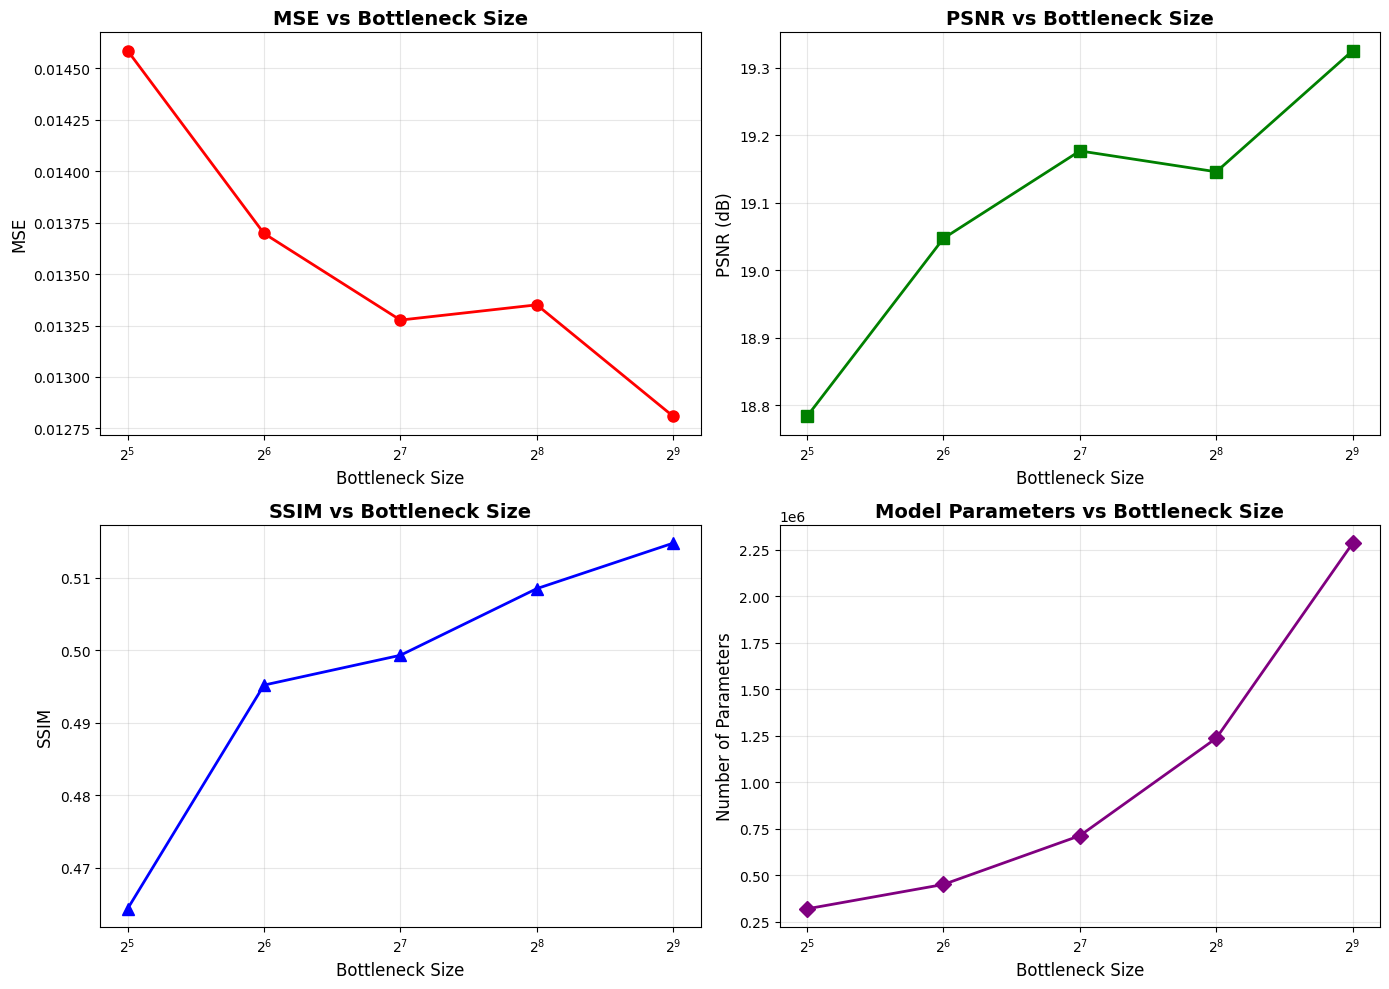


Observations:
- Larger bottleneck sizes generally lead to better reconstruction quality
- However, they also increase the number of model parameters
- There's a trade-off between compression and reconstruction accuracy
- Diminishing returns are observed beyond a certain bottleneck size


In [19]:
# Visualize the effect of bottleneck sizes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MSE vs Bottleneck Size
axes[0, 0].plot(bottleneck_results['bottleneck_size'], bottleneck_results['MSE'], 
                marker='o', color='red', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Bottleneck Size', fontsize=12)
axes[0, 0].set_ylabel('MSE', fontsize=12)
axes[0, 0].set_title('MSE vs Bottleneck Size', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log', base=2)

# PSNR vs Bottleneck Size
axes[0, 1].plot(bottleneck_results['bottleneck_size'], bottleneck_results['PSNR'], 
                marker='s', color='green', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Bottleneck Size', fontsize=12)
axes[0, 1].set_ylabel('PSNR (dB)', fontsize=12)
axes[0, 1].set_title('PSNR vs Bottleneck Size', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log', base=2)

# SSIM vs Bottleneck Size
axes[1, 0].plot(bottleneck_results['bottleneck_size'], bottleneck_results['SSIM'], 
                marker='^', color='blue', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Bottleneck Size', fontsize=12)
axes[1, 0].set_ylabel('SSIM', fontsize=12)
axes[1, 0].set_title('SSIM vs Bottleneck Size', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log', base=2)

# Parameters vs Bottleneck Size
axes[1, 1].plot(bottleneck_results['bottleneck_size'], bottleneck_results['params'], 
                marker='D', color='purple', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Bottleneck Size', fontsize=12)
axes[1, 1].set_ylabel('Number of Parameters', fontsize=12)
axes[1, 1].set_title('Model Parameters vs Bottleneck Size', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log', base=2)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Larger bottleneck sizes generally lead to better reconstruction quality")
print("- However, they also increase the number of model parameters")
print("- There's a trade-off between compression and reconstruction accuracy")
print("- Diminishing returns are observed beyond a certain bottleneck size")

### 8.3 Summary Tables and Conclusions

In [20]:
import pandas as pd

# Table 1: Gaussian Noise Level Experiment Results
print("=" * 80)
print("TABLE 1: Impact of Gaussian Noise Levels on Reconstruction Performance")
print("=" * 80)
df_gaussian = pd.DataFrame(gaussian_results)
df_gaussian.columns = ['Noise Level (σ)', 'MSE', 'PSNR (dB)', 'SSIM']
print(df_gaussian.to_string(index=False))
print()

# Table 2: Salt-and-Pepper Noise Level Experiment Results
print("=" * 80)
print("TABLE 2: Impact of Salt-and-Pepper Noise Levels on Reconstruction Performance")
print("=" * 80)
df_sp = pd.DataFrame(sp_results)
df_sp.columns = ['Noise Level (prob)', 'MSE', 'PSNR (dB)', 'SSIM']
print(df_sp.to_string(index=False))
print()

# Table 3: Bottleneck Size Experiment Results
print("=" * 80)
print("TABLE 3: Impact of Bottleneck Size on Reconstruction Performance")
print("=" * 80)
df_bottleneck = pd.DataFrame(bottleneck_results)
df_bottleneck.columns = ['Bottleneck Size', 'MSE', 'PSNR (dB)', 'SSIM', 'Parameters']
print(df_bottleneck.to_string(index=False))
print()

TABLE 1: Impact of Gaussian Noise Levels on Reconstruction Performance
 Noise Level (σ)      MSE  PSNR (dB)     SSIM
             0.1 0.011879  19.719603 0.547005
             0.2 0.012056  19.636836 0.535754
             0.3 0.013233  19.200624 0.501758
             0.4 0.014200  18.849455 0.479660
             0.5 0.016010  18.287536 0.454945

TABLE 2: Impact of Salt-and-Pepper Noise Levels on Reconstruction Performance
 Noise Level (prob)      MSE  PSNR (dB)     SSIM
               0.02 0.012403  19.527449 0.534203
               0.05 0.011954  19.676316 0.540039
               0.08 0.012860  19.335330 0.514535
               0.10 0.012691  19.404872 0.514174
               0.15 0.013884  18.986917 0.486402

TABLE 3: Impact of Bottleneck Size on Reconstruction Performance
 Bottleneck Size      MSE  PSNR (dB)     SSIM  Parameters
              32 0.014587  18.783753 0.464307      319523
              64 0.013698  19.047459 0.495201      450627
             128 0.013277  19.177043 0.4

## 9. Conclusions and Key Findings

### Summary of Results:

#### 1. **Two Specialized Models:**
   - We trained **two separate denoising autoencoder models**:
     - **Model 1**: Trained on Gaussian noise (σ = 0.3)
     - **Model 2**: Trained on Salt-and-Pepper noise (prob = 0.05)
   - Each model specializes in removing its respective noise type

#### 2. **Effect of Noise Levels:**
   - **Gaussian Noise**: Performance degrades gradually as noise intensity increases
   - **Salt-and-Pepper Noise**: Model shows good robustness up to moderate corruption levels
   - Higher noise levels lead to:
     - Increased MSE (worse reconstruction)
     - Decreased PSNR (lower quality)
     - Decreased SSIM (less structural similarity)

#### 3. **Effect of Bottleneck Size:**
   - **Smaller bottlenecks (32, 64)**: More compression but lower reconstruction quality
   - **Medium bottlenecks (128, 256)**: Good balance between compression and quality
   - **Larger bottlenecks (512)**: Best quality but diminishing returns and more parameters
   - Trade-off: Compression efficiency vs. reconstruction accuracy

#### 4. **Architecture Insights:**
   - Convolutional layers effectively capture spatial features
   - MaxPooling for downsampling and TransposeConv for upsampling work well
   - Sigmoid activation ensures output in valid pixel range [0, 1]
   - MSE loss is appropriate for pixel-wise reconstruction

#### 5. **Practical Recommendations:**
   - Use **separate models** for different noise types for best performance
   - Bottleneck size of **128-256** provides good balance for CIFAR-10 images
   - For real-world applications, consider ensemble methods or adaptive denoising
   - Training on mixed noise types may provide a more robust general-purpose denoiser

### Next Steps:
- Experiment with more advanced architectures (U-Net, ResNet-based autoencoders)
- Try perceptual loss functions (e.g., VGG-based) for better visual quality
- Implement attention mechanisms for better feature extraction
- Test on other datasets and real-world noisy images